In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as shc

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score



# Chargement
data = pd.read_csv('../poule-qui-chante/export/data_final_bis.csv', 
                    encoding='latin1', index_col=0)

print(f"Dimensions : {data.shape}")
display(data.head())

Dimensions : (138, 10)


,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
country,,,,,,,,,,
Armenia,0.643592,-7.177995,4372.939704,69.490997,2832000.0,-0.77,97.62,48.531650,7.41,15.37
Australia,0.850834,4.200123,55758.834562,44.039528,-1104000.0,0.86,108.73,74.880290,21.25,10.72
India,0.344426,-6.144681,1910.271668,37.870998,2740000.0,-0.84,64.82,15.347798,1.44,5.69
Indonesia,0.561063,-5.365475,3853.702895,33.190590,31557000.0,-0.46,54.92,26.853527,6.04,8.44
Ireland,0.624440,7.228912,87615.893087,239.951034,4922000.0,0.97,108.69,72.767200,18.67,9.05


# Classification Ascendante Hiérarchique (CAH)

In [2]:
features = [col for col in data.columns if not col.startswith('Cluster')]

In [3]:
scaler = StandardScaler()
scaler_minmax = MinMaxScaler()


X_scaled = scaler.fit_transform(data[features])
X = pd.DataFrame(X_scaled, index=data.index, columns=features)

Z = linkage(X, method='ward', optimal_ordering=True, metric='euclidean')

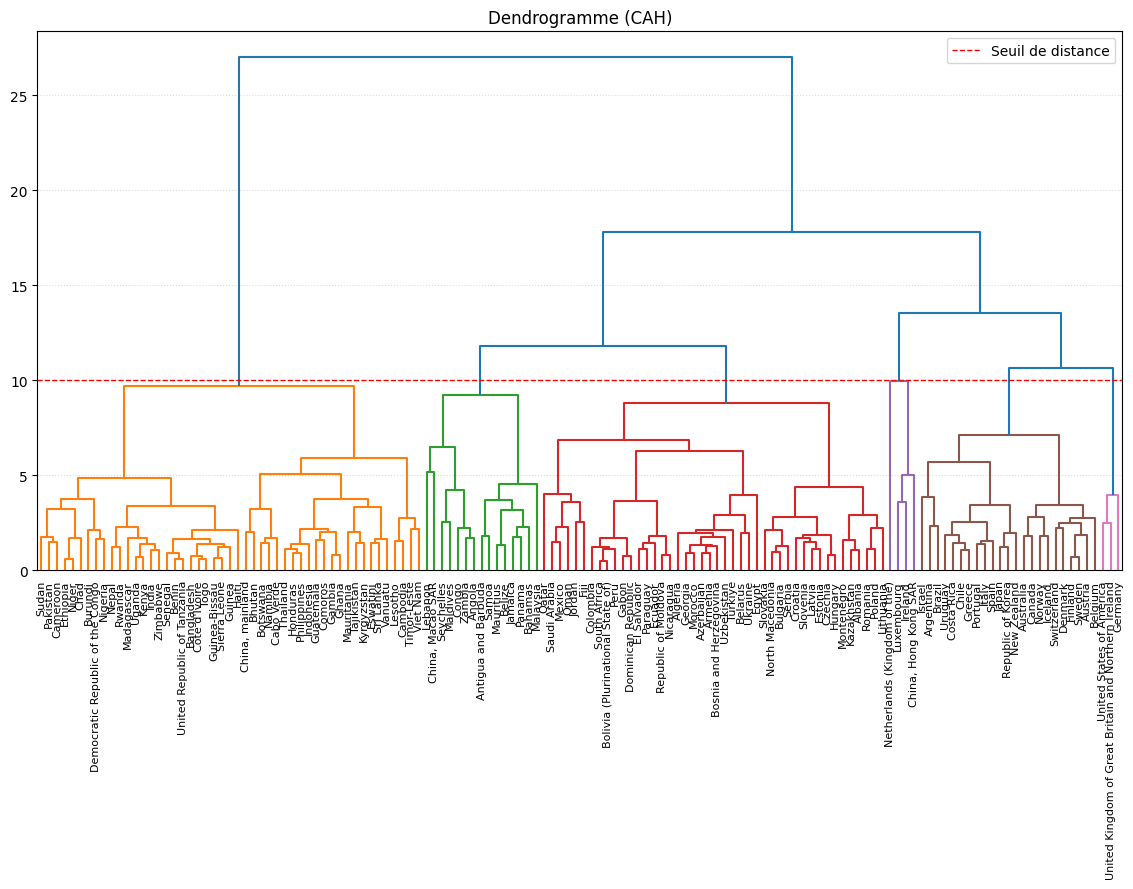

In [4]:
# Dendrogramme

limit = 10  # Seuil de distance pour couper le dendrogramme

plt.figure(figsize=(14, 7))
dendrogram(Z, labels=X.index, leaf_rotation=90, leaf_font_size=8, color_threshold=limit)
plt.title("Dendrogramme (CAH)")
plt.grid(axis='y', color='gainsboro', linestyle='dotted')
plt.axhline(y=limit, color='red', lw=1, linestyle='dashed', label='Seuil de distance')
plt.legend()
plt.show()

In [5]:
# Découpage en k clusters (par exemple k=6) avec maxclust car on va comparer avec une autre méthode
k_cah = 6

clusters_cah = fcluster(Z, k_cah, criterion='maxclust')
data['Cluster_CAH'] = clusters_cah
display(data[['Cluster_CAH']])

,Cluster_CAH
country,
Armenia,3
Australia,5
India,1
Indonesia,1
Ireland,4
...,...
Honduras,1
"China, Hong Kong SAR",4
Hungary,3


In [6]:
for i in sorted(data['Cluster_CAH'].unique()):
    print(f"\nCluster {i}:")
    print(", ".join(data[data['Cluster_CAH'] == i].index))


Cluster 1:
India, Indonesia, Côte d'Ivoire, Kyrgyzstan, Kenya, Cambodia, Lesotho, Madagascar, Mauritania, Namibia, Nepal, Vanuatu, Niger, Nigeria, Bangladesh, Pakistan, Philippines, Guinea-Bissau, Timor-Leste, Bhutan, Zimbabwe, Rwanda, Senegal, Sierra Leone, Botswana, Tajikistan, Eswatini, United Republic of Tanzania, Thailand, Togo, Uganda, Viet Nam, Ethiopia, Democratic Republic of the Congo, Sudan, Burundi, Cameroon, Cabo Verde, Sri Lanka, Chad, China, mainland, Comoros, Benin, Gambia, Ghana, Guatemala, Guinea, Haiti, Honduras

Cluster 2:
Jamaica, Bahamas, Lebanon, China, Macao SAR, Malaysia, Maldives, Mauritius, Panama, Seychelles, Belize, Samoa, Zambia, Congo, Angola, Antigua and Barbuda

Cluster 3:
Armenia, Kazakhstan, Jordan, Latvia, Lithuania, Mexico, Morocco, Republic of Moldova, North Macedonia, Nicaragua, Czechia, Paraguay, Peru, Poland, Qatar, Romania, Bolivia (Plurinational State of), Saudi Arabia, Slovenia, Slovakia, South Africa, Oman, Türkiye, Ukraine, Uzbekistan, Bulg

In [7]:
# Moyenne des variables pour chaque cluster
cluster_profile_cah = data.groupby('Cluster_CAH')[features].mean()

print("Profil moyen par cluster (CAH) :")
display(cluster_profile_cah)

Profil moyen par cluster (CAH) :


,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
Cluster_CAH,,,,,,,,,,
1,0.399372,-1.311030,2137.201675,60.923659,4.206286e+06,-0.522041,61.067143,18.179642,3.269796,7.417551
2,0.578476,-24.733060,10089.127558,92.334175,-6.981733e+06,0.304000,66.986000,39.255930,16.826000,12.254667
3,0.685863,-5.435317,10248.241886,83.963018,6.239886e+06,-0.103636,86.877955,43.729775,10.715909,15.978182
4,0.851631,2.019496,75854.101361,278.303677,9.451950e+07,0.767500,110.120000,79.257475,13.512500,7.785000
5,0.833428,-4.442664,38598.834357,67.844245,-2.029478e+06,0.670870,97.276957,63.606199,12.644348,9.297391
6,0.803469,-2.239063,50021.787717,53.531177,-2.418130e+08,0.363333,104.830000,67.373412,14.050000,10.963333


In [8]:
# Normalisation 
cluster_profile_cah_norm = pd.DataFrame(
    scaler_minmax.fit_transform(cluster_profile_cah),
    columns=cluster_profile_cah.columns,
    index=cluster_profile_cah.index
)


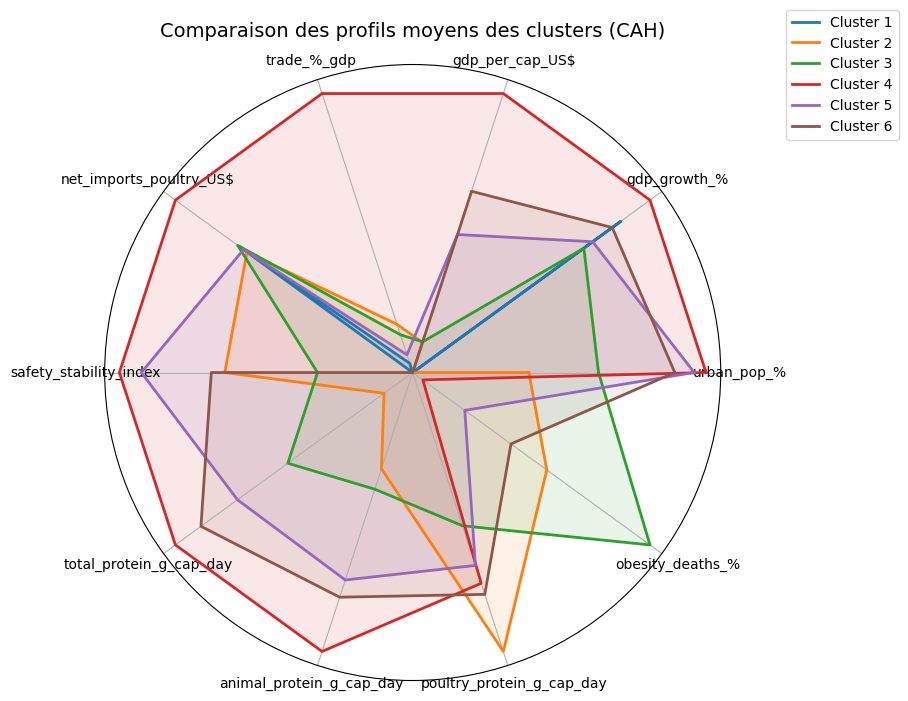

In [9]:

variables = cluster_profile_cah_norm.columns
N = len(variables)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_num in cluster_profile_cah_norm.index:
    values = cluster_profile_cah_norm.loc[cluster_num].tolist()
    values += values[:1]  
    ax.plot(angles, values, label=f"Cluster {cluster_num}", linewidth=2)
    ax.fill(angles, values, alpha=0.1)   

ax.set_xticks(angles[:-1])
ax.set_xticklabels(variables, fontsize=10)
ax.set_yticks([])
ax.set_title("Comparaison des profils moyens des clusters (CAH)", size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

In [10]:
for i in range(1, k_cah+1):
    print(f"Cluster {i}:")
    print(data[data['Cluster_CAH'] == i].index.tolist())
    print("\n")

Cluster 1:
['India', 'Indonesia', "Côte d'Ivoire", 'Kyrgyzstan', 'Kenya', 'Cambodia', 'Lesotho', 'Madagascar', 'Mauritania', 'Namibia', 'Nepal', 'Vanuatu', 'Niger', 'Nigeria', 'Bangladesh', 'Pakistan', 'Philippines', 'Guinea-Bissau', 'Timor-Leste', 'Bhutan', 'Zimbabwe', 'Rwanda', 'Senegal', 'Sierra Leone', 'Botswana', 'Tajikistan', 'Eswatini', 'United Republic of Tanzania', 'Thailand', 'Togo', 'Uganda', 'Viet Nam', 'Ethiopia', 'Democratic Republic of the Congo', 'Sudan', 'Burundi', 'Cameroon', 'Cabo Verde', 'Sri Lanka', 'Chad', 'China, mainland', 'Comoros', 'Benin', 'Gambia', 'Ghana', 'Guatemala', 'Guinea', 'Haiti', 'Honduras']


Cluster 2:
['Jamaica', 'Bahamas', 'Lebanon', 'China, Macao SAR', 'Malaysia', 'Maldives', 'Mauritius', 'Panama', 'Seychelles', 'Belize', 'Samoa', 'Zambia', 'Congo', 'Angola', 'Antigua and Barbuda']


Cluster 3:
['Armenia', 'Kazakhstan', 'Jordan', 'Latvia', 'Lithuania', 'Mexico', 'Morocco', 'Republic of Moldova', 'North Macedonia', 'Nicaragua', 'Czechia', 'Parag

# K-Means

In [11]:

scaler = StandardScaler()
X_scaled_kmeans = scaler.fit_transform(data[features])


In [12]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled_kmeans)
data['Cluster_Kmeans'] = clusters_kmeans + 1  

print("Répartition des clusters K-Means :")
display(data[['Cluster_Kmeans']])

Répartition des clusters K-Means :


,Cluster_Kmeans
country,
Armenia,5
Australia,4
India,1
Indonesia,1
Ireland,3
...,...
Honduras,1
"China, Hong Kong SAR",3
Hungary,5


In [13]:
cluster_profile_kmeans = data.groupby('Cluster_Kmeans')[features].mean()
print("Profil moyen par cluster (K-Means) :")
display(cluster_profile_kmeans)

Profil moyen par cluster (K-Means) :


,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
Cluster_Kmeans,,,,,,,,,,
1,0.382569,-1.826141,1759.046143,56.286091,3.283364e+06,-0.650000,57.274545,15.614212,3.030909,7.081364
2,0.712391,-18.014323,11282.239852,73.588168,-2.466533e+06,0.160000,75.694000,42.322907,17.488667,13.955333
3,0.835995,2.561400,83513.448195,322.636693,2.233667e+06,0.746667,111.550000,82.452823,16.816667,7.933333
4,0.814752,-2.501302,43377.716253,75.508667,-3.117862e+07,0.753333,99.414167,65.975760,11.793750,9.593750
5,0.617911,-2.846600,7996.960442,91.367079,7.823194e+06,-0.092778,88.742500,42.463431,7.666944,14.904444
6,0.898538,0.393782,52876.060859,145.304627,3.713770e+08,0.830000,105.830000,69.671430,3.600000,7.340000


In [14]:
cluster_profile_kmeans_norm = pd.DataFrame(
    scaler_minmax.fit_transform(cluster_profile_kmeans),
    columns=cluster_profile_kmeans.columns,
    index=cluster_profile_kmeans.index
)


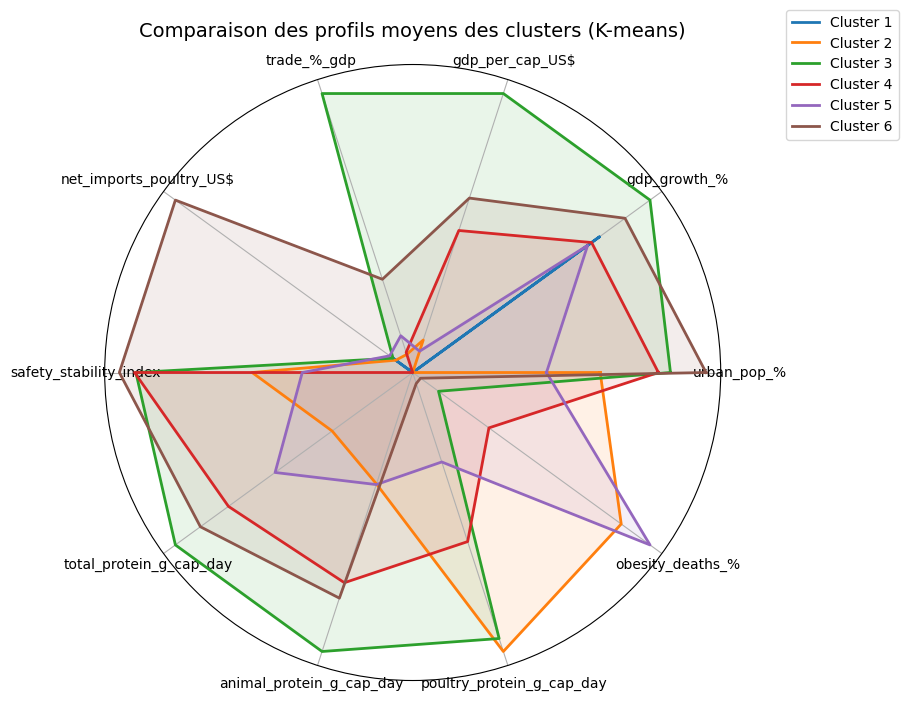

In [15]:

variables = cluster_profile_kmeans_norm.columns
N = len(variables)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_num in cluster_profile_kmeans_norm.index:
    values = cluster_profile_kmeans_norm.loc[cluster_num].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster_num}")
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(variables, fontsize=10)
ax.set_yticks([])
ax.set_title("Comparaison des profils moyens des clusters (K-means)", size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

In [16]:
print("Profil K-Means :")
display(cluster_profile_kmeans)

Profil K-Means :


,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
Cluster_Kmeans,,,,,,,,,,
1,0.382569,-1.826141,1759.046143,56.286091,3.283364e+06,-0.650000,57.274545,15.614212,3.030909,7.081364
2,0.712391,-18.014323,11282.239852,73.588168,-2.466533e+06,0.160000,75.694000,42.322907,17.488667,13.955333
3,0.835995,2.561400,83513.448195,322.636693,2.233667e+06,0.746667,111.550000,82.452823,16.816667,7.933333
4,0.814752,-2.501302,43377.716253,75.508667,-3.117862e+07,0.753333,99.414167,65.975760,11.793750,9.593750
5,0.617911,-2.846600,7996.960442,91.367079,7.823194e+06,-0.092778,88.742500,42.463431,7.666944,14.904444
6,0.898538,0.393782,52876.060859,145.304627,3.713770e+08,0.830000,105.830000,69.671430,3.600000,7.340000


In [17]:
centroids_real = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features)

In [18]:
print("Centroïdes K-means (valeurs réelles) :")
display(centroids_real)

Centroïdes K-means (valeurs réelles) :


,urban_pop_%,gdp_growth_%,gdp_per_cap_US$,trade_%_gdp,net_imports_poultry_US$,safety_stability_index,total_protein_g_cap_day,animal_protein_g_cap_day,poultry_protein_g_cap_day,obesity_deaths_%
0,0.382569,-1.826141,1759.046143,56.286091,3.283364e+06,-0.650000,57.274545,15.614212,3.030909,7.081364
1,0.712391,-18.014323,11282.239852,73.588168,-2.466533e+06,0.160000,75.694000,42.322907,17.488667,13.955333
2,0.835995,2.561400,83513.448195,322.636693,2.233667e+06,0.746667,111.550000,82.452823,16.816667,7.933333
3,0.814752,-2.501303,43377.716253,75.508667,-3.117862e+07,0.753333,99.414167,65.975760,11.793750,9.593750
4,0.617911,-2.846600,7996.960442,91.367079,7.823194e+06,-0.092778,88.742500,42.463431,7.666944,14.904444
5,0.898538,0.393782,52876.060859,145.304627,3.713770e+08,0.830000,105.830000,69.671430,3.600000,7.340000


In [19]:
scaler_radar = MinMaxScaler()
centroids_norm = pd.DataFrame(
    scaler_radar.fit_transform(centroids_real),
    columns=centroids_real.columns
)

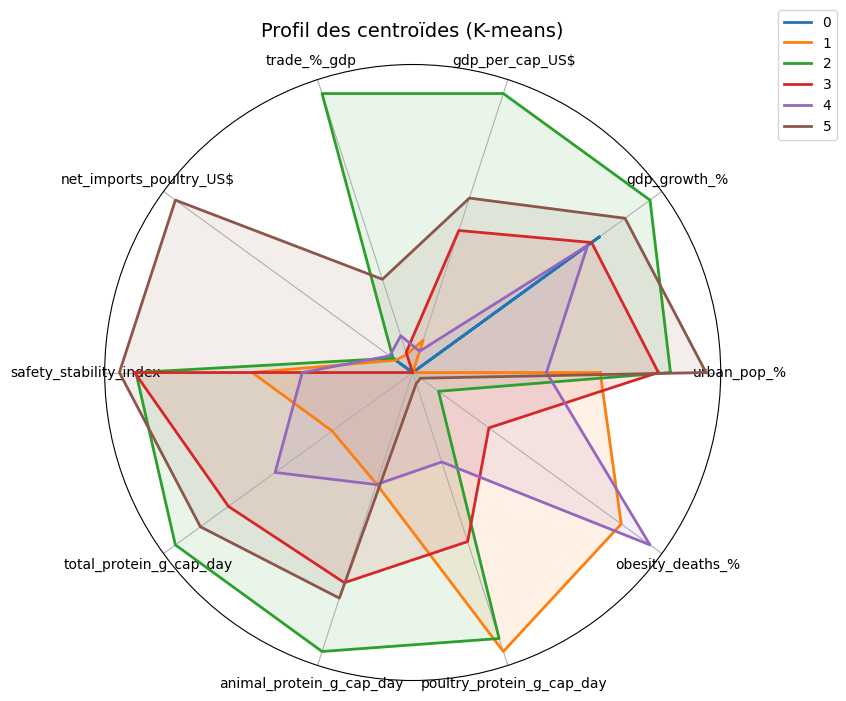

In [20]:

# Radar chart
variables = centroids_norm.columns
N = len(variables)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for idx in centroids_norm.index:
    values = centroids_norm.loc[idx].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=idx)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(variables, fontsize=10)
ax.set_yticks([])
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
ax.set_title("Profil des centroïdes (K-means)", size=14, pad=20)

plt.show()

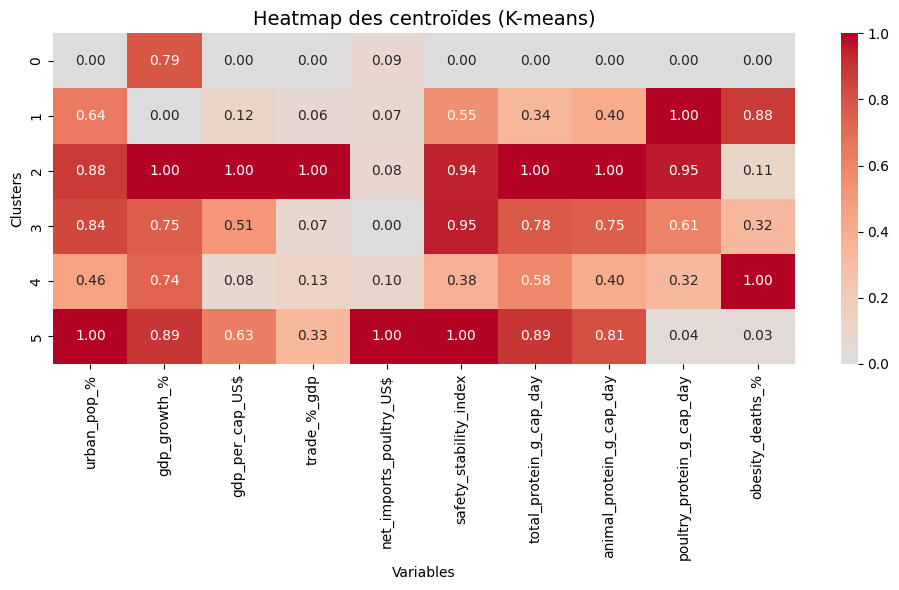

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(centroids_norm, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Heatmap des centroïdes (K-means)", fontsize=14)
plt.ylabel("Clusters")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

In [22]:
# Table de correspondance entre clusters CAH et K-means
table_corr = pd.crosstab(data['Cluster_CAH'], data['Cluster_Kmeans'])

table_corr

Cluster_Kmeans,1,2,3,4,5,6
Cluster_CAH,,,,,,
1,42,1,0,0,6,0
2,2,13,0,0,0,0
3,0,12,0,2,30,0
4,0,0,3,0,0,1
5,0,4,0,19,0,0
6,0,0,0,3,0,0


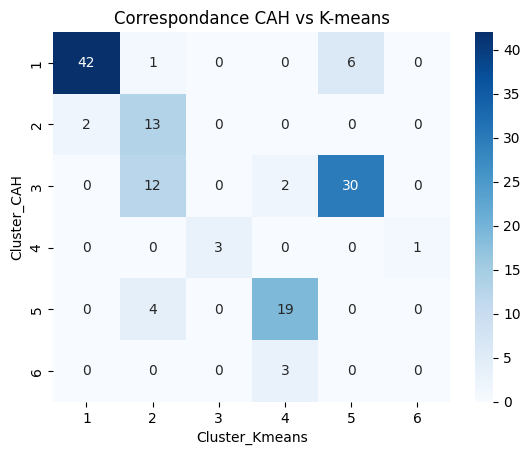

In [23]:
sns.heatmap(table_corr, annot=True, fmt="d", cmap="Blues")
plt.title("Correspondance CAH vs K-means")
plt.show()

	•	Le cluster CAH 1 correspond majoritairement au cluster K-means 1 (42 pays) avec quelques pays dispersés dans K-means 2 (2 pays).
	•	Le cluster CAH 2 est plus éclaté entre K-means 2 (13 pays), K-means 3 (12 pays) et K-means 5 (4 pays).
	•	Le cluster CAH 5 correspond principalement au cluster K-means 3 (30 pays) mais a aussi 6 pays dans K-means 1.
	•	Certains clusters CAH sont très peu représentés ou fragmentés (ex. CAH 3, 4, 6).

In [ ]:

labels_cah = data['Cluster_CAH']
labels_kmeans = data['Cluster_Kmeans']

ari = adjusted_rand_score(labels_cah, labels_kmeans)
print(f"Adjusted Rand Index entre CAH et K-means : {ari:.3f}")

Adjusted Rand Index entre CAH et K-means : 0.580


# ARI est de 0,58 ce qui tend vers 1 et donc les partitions tendes vers une similarité qu'il faudra approfondir par la suite

# ACP

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data) 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


Variance expliquée par les 2 premières composantes : [0.43356923 0.56056055]
Variance expliquée cumulée : [0.43356923 0.99412979]


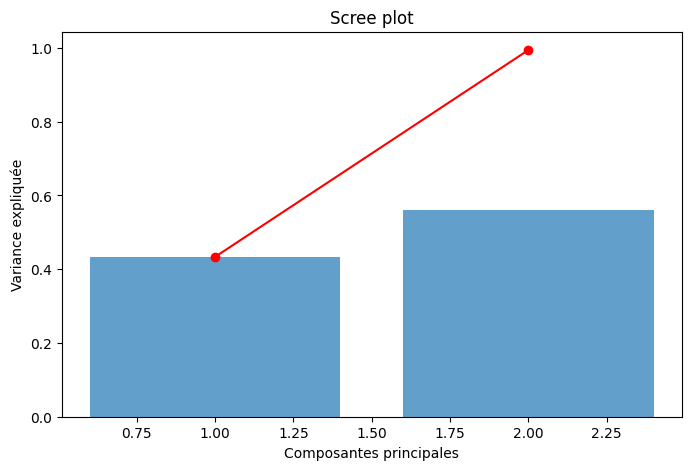

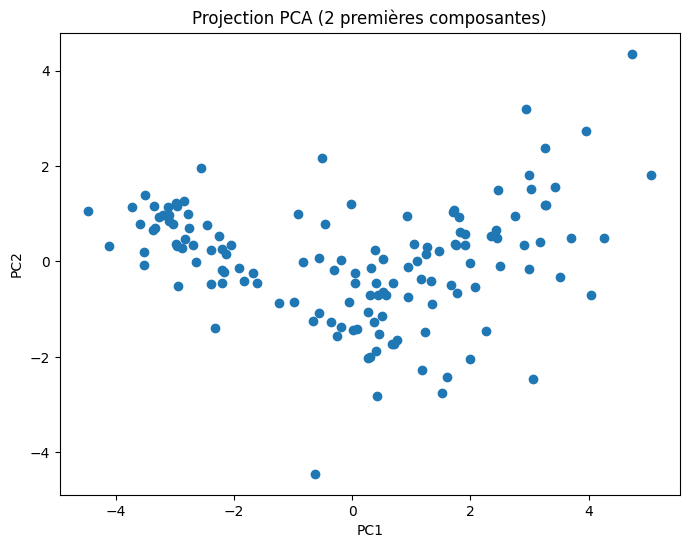

In [26]:

explained_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance expliquée par les 2 premières composantes : {explained_var[:2]}")
print(f"Variance expliquée cumulée : {explained_var.cumsum()}")


plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.7)
plt.plot(range(1, len(explained_var)+1), explained_var.cumsum(), marker='o', color='red')
plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée")
plt.title("Scree plot")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection PCA (2 premières composantes)")
plt.show()

In [27]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index= data.index)
pca_df['Cluster_CAH'] = data['Cluster_CAH']
pca_df['Cluster_Kmeans'] = data['Cluster_Kmeans']

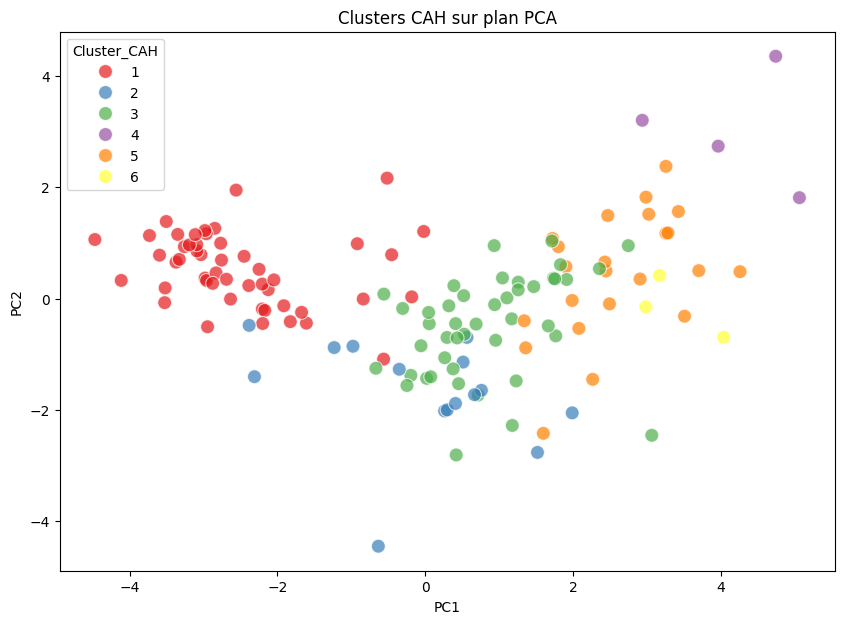

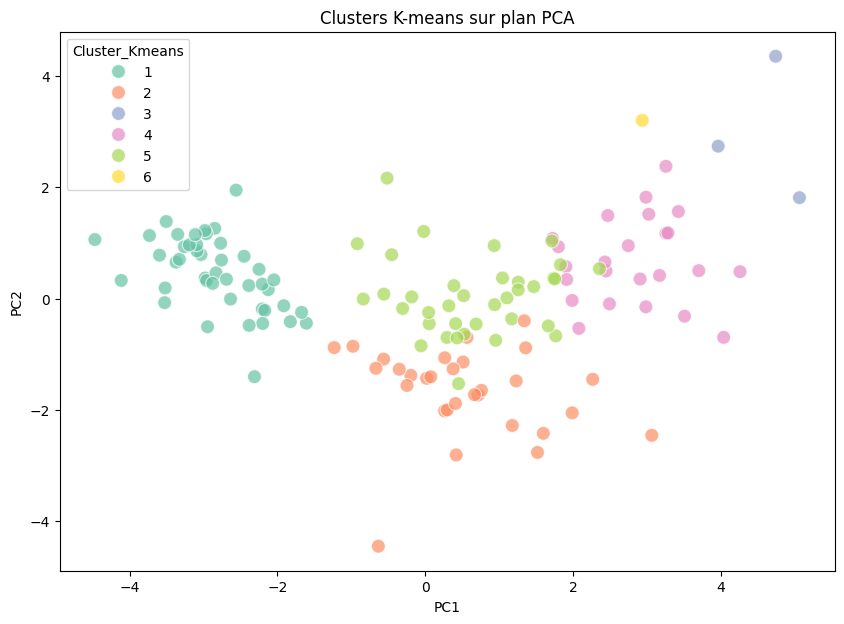

In [28]:

plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster_CAH', palette='Set1', s=100, alpha=0.7)
plt.title("Clusters CAH sur plan PCA")
plt.show()

plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster_Kmeans', palette='Set2', s=100, alpha=0.7)
plt.title("Clusters K-means sur plan PCA")
plt.show()

In [29]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=data.columns)
print(loadings)

                                PC1       PC2
urban_pop_%                0.343111 -0.173628
gdp_growth_%              -0.043557  0.585809
gdp_per_cap_US$            0.335120  0.303069
trade_%_gdp                0.187632  0.310843
net_imports_poultry_US$   -0.046412  0.134119
safety_stability_index     0.293919  0.088948
total_protein_g_cap_day    0.373164  0.086827
animal_protein_g_cap_day   0.412132  0.058072
poultry_protein_g_cap_day  0.268544 -0.409511
obesity_deaths_%           0.170278 -0.469992
Cluster_CAH                0.381526  0.014570
Cluster_Kmeans             0.297570  0.112211


Interprétation des composantes principales (PC1 & PC2)

PC1 — Axe principal (explique la plus grande part de variance)
		•	Variables les plus positives sur PC1 :
		•	animal_protein_g_cap_day (0.41)
		•	total_protein_g_cap_day (0.37)
		•	Cluster_CAH (0.38)
		•	urban_pop_% (0.34)
		•	gdp_per_cap_US$ (0.34)
		•	safety_stability_index (0.29)
		•	poultry_protein_g_cap_day (0.27)

Variables négatives ou faibles :
		•	gdp_growth_% (-0.04), net_imports_poultry_US$ (-0.05) (faibles contributions négatives)

Interprétation :
PC1 semble représenter un axe de “niveau de développement socio-économique et nutritionnel” :
	•	Plus un pays est sur la droite (PC1 élevée), plus il a :
	•	Une population urbaine importante
	•	Un PIB par habitant élevé
	•	Un indice de sécurité/stabilité élevé
	•	Une consommation de protéines (totales, animales et volaille) élevée
	•	Cela correspond aussi à la contribution forte des clusters CAH et Kmeans, donc ces clusters se distinguent bien sur cet axe.

PC2 — Deuxième axe (explique la deuxième part de variance)
	•	Variables les plus positives sur PC2 :
	•	gdp_growth_% (0.59)
	•	trade_%_gdp (0.31)
	•	gdp_per_cap_US$ (0.30)
	•	Variables les plus négatives sur PC2 :
	•	obesity_deaths_% (-0.47)
	•	poultry_protein_g_cap_day (-0.41)
	•	urban_pop_% (-0.17)

Interprétation :
PC2 semble capter un axe lié à la dynamique économique et certains comportements alimentaires :
	•	En haut (valeurs positives PC2), les pays ont :
	•	Une croissance économique forte
	•	Un commerce extérieur important
	•	En bas (valeurs négatives PC2), les pays ont :
	•	Plus d’obésité liée aux décès
	•	Une consommation de protéines volaille plus faible
	•	Une urbanisation plus faible


En résumé
	•	PC1 : Axe développement et nutrition (richesse, urbanisation, protéines)
	•	PC2 : Axe croissance économique vs impact santé (obésité), avec un contraste dans la consommation de protéines volaille

In [ ]:
# Transformation des données avec l'ACP
scores = pca.transform(X_scaled)  # X_scaled est la version normalisée de ton dataset

# Créer un DataFrame avec les pays comme index
scores_df = pd.DataFrame(scores[:, :2],  # On ne prend que PC1 et PC2
                        columns=['PC1', 'PC2'],
                        index=data.index)

print(scores_df)

                           PC1       PC2
country                                 
Armenia               0.688665 -0.457831
Australia             3.702372  0.501853
India                -2.977705  0.368769
Indonesia            -2.203914 -0.186352
Ireland               3.964414  2.738437
...                        ...       ...
Honduras             -1.825006 -0.414087
China, Hong Kong SAR  5.063925  1.812623
Hungary               1.752940  0.354063
Croatia               1.258285  0.157019
Iceland               4.260076  0.483331

[138 rows x 2 columns]


In [31]:
# Pays avec les valeurs les plus fortes sur PC1
top_PC1 = scores_df.sort_values(by='PC1', ascending=False).head(10)
print(top_PC1)

# Pays les plus faibles sur PC1
low_PC1 = scores_df.sort_values(by='PC1', ascending=True).head(10)
print(low_PC1)

                               PC1       PC2
country                                     
China, Hong Kong SAR      5.063925  1.812623
Luxembourg                4.742858  4.353391
Iceland                   4.260076  0.483331
United States of America  4.039065 -0.696011
Ireland                   3.964414  2.738437
Australia                 3.702372  0.501853
Israel                    3.509301 -0.316077
Denmark                   3.426103  1.563706
Finland                   3.284390  1.178746
Norway                    3.258246  1.173859
                                       PC1       PC2
country                                             
Burundi                          -4.469745  1.060681
Democratic Republic of the Congo -4.113354  0.326234
Ethiopia                         -3.731016  1.132883
Uganda                           -3.594899  0.779983
Nigeria                          -3.525009 -0.073055
Madagascar                       -3.519142  0.190862
Niger                            -3.

In [32]:
data.to_csv("../poule-qui-chante/export/resultats_clusters.csv")
print("Résultats sauvegardés dans resultats_clusters.csv")

Résultats sauvegardés dans resultats_clusters.csv
